# Day 4｜AI 廣告精準投放與全通路行銷成效優化

## 從漏斗績效到可控的投放實驗

> **資料使用邊界：** 本 Notebook 使用固定亂數種子產生的教學虛擬資料，不是任何企業的真實營運資料。結果只能用於練習分析流程，不可宣稱為企業事實或因果效果。

### 故事情境

第四天早上，主管把下個月預算放到桌上：四家企業都累積了跨通路虛擬接觸資料，但每個企業部門都說自己的渠道最好。你要在下午前回答：預算應維持、加碼或轉移到哪裡？模型要抓更多可能轉換者，還是少打擾不會轉換的人？哪些結論仍需要實驗？

### 今日決策問題

**如何同時用漏斗 KPI、轉換機率與錯誤成本決定預算配置及下一個實驗？**

### 學習目標

- 能正確計算 CTR、CVR、CPA、ROAS 與貢獻毛利
- 能建立 logistic regression 轉換模型
- 能用混淆矩陣、precision、recall、ROC-AUC 評估
- 能依錯誤成本調整分類門檻
- 能提出有規模與風險邊界的全通路預算方案

### Colab 操作提醒

1. 在 Google Drive 建立個人副本。
2. 將對應 CSV 上傳到 Colab `/content`，或保持教材包原始相對路徑。
3. 由上到下依序執行；若 Runtime 重啟，請重新執行全部儲存格。
4. 每個程式碼儲存格後都有繁體中文說明、預期輸出與完成檢核。

> **明志科技大學 M4｜寶島眼鏡 專屬 Notebook**
>
> 教學設計與教材製作｜恩恩統計家教
>
> www.enentutor.com

#### 第一次使用 Google Colab

1. 登入 Google 帳號後，選擇「檔案 → 在雲端硬碟中儲存副本」。
2. 依頁面順序按儲存格左側播放鍵；也可按 `Shift+Enter` 執行目前儲存格。
3. 星號表示正在執行，綠色勾選表示完成；看到紅字時先讀最末一行。
4. 若執行順序混亂，選擇「執行階段 → 重新啟動工作階段並全部執行」。
5. 本 Notebook 已綁定 寶島眼鏡，不需修改企業名稱；Raw 失敗時才上傳同企業 CSV 到 `/content`。

### [D4-S01] 載入全通路資料並建立決策邊界

In [1]:
# 本格目的：載入套件並找到教學資料檔
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# 中文圖表字型設定（Windows／macOS／Linux／Google Colab）
import hashlib
import os
import sys
from pathlib import Path
from urllib.request import urlretrieve
import matplotlib as mpl
from matplotlib import font_manager
from matplotlib.ft2font import FT2Font

FONT_URL = "https://raw.githubusercontent.com/notofonts/noto-cjk/f8d157532fbfaeda587e826d4cd5b21a49186f7c/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf"
FONT_SHA256 = "dce08bd4fd91aa8aa76ed8fea4b694c2dfb8550f67871e326843212ddbeb88b4"
font_override = os.environ.get("M4_FONT_PATH")
FONT_FILE_CANDIDATES = [
    *([Path(font_override)] if font_override else []),
    Path("C:/Windows/Fonts/msjh.ttc"),
    Path("C:/Windows/Fonts/msjhbd.ttc"),
    Path("/usr/share/fonts/opentype/noto/NotoSansCJKtc-Regular.otf"),
    Path("/usr/share/fonts/truetype/noto/NotoSansTC-Regular.ttf"),
    Path("/usr/local/share/fonts/NotoSansTC-Regular.ttf"),
    Path("/System/Library/Fonts/PingFang.ttc"),
]

font_path = next((path for path in FONT_FILE_CANDIDATES if path.is_file()), None)
in_colab = (
    "google.colab" in sys.modules
    or "COLAB_RELEASE_TAG" in os.environ
    or "COLAB_BACKEND_VERSION" in os.environ
    or Path("/content").is_dir()
)
allow_download = in_colab or os.environ.get("M4_DOWNLOAD_CJK_FONT") == "1"
if font_path is None and allow_download:
    font_cache = Path("/content/.cache/m4-fonts") if in_colab else Path.home() / ".cache" / "m4-fonts"
    font_cache.mkdir(parents=True, exist_ok=True)
    downloaded_font = font_cache / "NotoSansCJKtc-Regular.otf"
    if downloaded_font.is_file() and hashlib.sha256(downloaded_font.read_bytes()).hexdigest() != FONT_SHA256:
        downloaded_font.unlink()
    if not downloaded_font.is_file():
        temporary_font = downloaded_font.with_suffix(".download")
        temporary_font.unlink(missing_ok=True)
        try:
            urlretrieve(FONT_URL, temporary_font)
        except (OSError, ValueError) as exc:
            temporary_font.unlink(missing_ok=True)
            raise RuntimeError("無法下載免費的 Noto Sans TC 字型，請確認網路後重新執行本格。") from exc
        if hashlib.sha256(temporary_font.read_bytes()).hexdigest() != FONT_SHA256:
            temporary_font.unlink(missing_ok=True)
            raise RuntimeError("下載的 Noto Sans TC 字型檔驗證失敗，請重新執行本格。")
        temporary_font.replace(downloaded_font)
    font_path = downloaded_font

if font_path is None:
    raise RuntimeError(
        "找不到可顯示繁體中文的字型；本機請安裝免費的 Noto Sans TC，"
        "或設定 M4_FONT_PATH 指向字型檔。"
    )

font_path = font_path.resolve()
try:
    # 使用公開 API，把實際字型檔加入「目前這次執行」的 FontManager。
    font_manager.fontManager.addfont(str(font_path))
except (OSError, RuntimeError) as exc:
    raise RuntimeError(f"Matplotlib 無法載入中文字型檔：{font_path}") from exc

registered_font = next(
    (
        entry
        for entry in reversed(font_manager.fontManager.ttflist)
        if Path(entry.fname).resolve() == font_path
    ),
    None,
)
if registered_font is None:
    raise RuntimeError(f"中文字型未成功註冊到目前的 Matplotlib：{font_path}")
font_name = registered_font.name

font_rc = {
    "font.family": font_name,
    "font.sans-serif": [font_name],
    "axes.unicode_minus": False,
}
sns.set_theme(style="whitegrid", rc=font_rc)
mpl.rcParams.update(font_rc)

# 驗證 Matplotlib 真的能用已註冊的名稱找到字型，而且含課程常用繁中文字元。
try:
    resolved_font = font_manager.findfont(
        font_manager.FontProperties(family=[font_name]),
        fallback_to_default=False,
    )
except ValueError as exc:
    raise RuntimeError(f"Matplotlib 找不到剛註冊的中文字型：{font_name}") from exc
font_face = FT2Font(resolved_font)
required_text = "繁體中文圖表標題座標軸月份需求價格廣告預測實際值"
missing_glyphs = sorted(
    {char for char in required_text if font_face.get_char_index(ord(char)) == 0}
)
if missing_glyphs:
    raise RuntimeError(f"中文字型缺少必要字元：{missing_glyphs}")

# Plotly 若已安裝，同步設定預設範本；未安裝時不增加課堂錯誤。
try:
    import plotly.io as pio

    pio.templates.default = "plotly_white"
    pio.templates["plotly_white"].layout.font.family = f'"{font_name}", sans-serif'
except (ImportError, KeyError, AttributeError):
    pass
print(f"圖表中文字型：{font_name}（{resolved_font}）")

# 優先從公開 GitHub Raw 讀取企業專屬資料；失敗時再依序尋找 /content 與本機相對路徑
import os

ENTERPRISE_ID = "formosa-optical"
ENTERPRISE_NAME = "寶島眼鏡"
ENTERPRISE_DISPLAY_NAME = "寶島眼鏡"
RAW_DATA_URL = "https://raw.githubusercontent.com/johnnychao/mcut-m4-business-analytics-2026-student/main/docs/resources/data/formosa-optical/day-4-formosa-optical-omnichannel-ads.csv"
DATA_FILENAME = "day-4-formosa-optical-omnichannel-ads.csv"
FORCE_LOCAL_DATA = os.environ.get("M4_FORCE_LOCAL_DATA") == "1"

try:
    # 正式教材 QA 可關閉遠端來源，確認企業專屬本機資料能獨立運作
    if FORCE_LOCAL_DATA:
        raise ConnectionError("M4 Notebook QA：改用本機資料備援")
    df = pd.read_csv(RAW_DATA_URL)
    data_source = RAW_DATA_URL
except Exception as remote_error:
    candidate_paths = [
        Path("/content") / DATA_FILENAME,
        Path(DATA_FILENAME),
        Path("../04_data") / ENTERPRISE_ID / DATA_FILENAME,
        Path("../../04_data") / ENTERPRISE_ID / DATA_FILENAME,
    ]
    data_path = next((path for path in candidate_paths if path.exists()), None)
    if data_path is None:
        raise FileNotFoundError(
            f"GitHub Raw 暫時無法讀取，而且 /content 與本機相對路徑都找不到 {DATA_FILENAME}。"
        ) from remote_error
    df = pd.read_csv(data_path)
    data_source = str(data_path)

# 企業專屬 CSV 應只有一家公司；若不一致就立即停止，避免跨企業混算
if df["company"].nunique() != 1 or str(df["company"].iloc[0]) != ENTERPRISE_NAME:
    raise ValueError(f"資料企業不符：預期 {ENTERPRISE_NAME}，實際 {df['company'].unique().tolist()}")

# 所有課堂匯出檔依企業集中，避免 16 本 Notebook 的輸出互相覆蓋
OUTPUT_DIR = Path("outputs") / ENTERPRISE_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"企業情境：{ENTERPRISE_DISPLAY_NAME}")
print(f"資料來源：{data_source}")
print(f"資料尺寸：{df.shape}")
display(df.head(3))

圖表中文字型：Microsoft JhengHei
企業情境：寶島眼鏡
資料來源：..\04_data\formosa-optical\day-4-formosa-optical-omnichannel-ads.csv
資料尺寸：(1500, 14)


,date,company,channel,audience_segment,creative_type,device,impression,clicked,visited,converted,spend,revenue,unit_margin_rate,is_synthetic
0,2025-10-01,寶島眼鏡,Meta,新客探索,短影音,desktop,1,0,0,0,4.330,0.000,0.540,True
1,2025-10-02,寶島眼鏡,Google,新客探索,短影音,desktop,1,0,0,0,6.390,0.000,0.540,True
2,2025-10-03,寶島眼鏡,LINE,新客探索,短影音,desktop,1,0,0,0,3.900,0.000,0.540,True


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 載入 6,000 筆虛擬全通路接觸資料。
- **預期輸出：** 資料尺寸與前三列。
- **完成檢核：** 資料包含四家公司與 is_synthetic。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D4-S02] 確認綁定企業並檢查漏斗邏輯

In [2]:
# 本格目的：選定企業並確認曝光、點擊、造訪、轉換的順序
assert df["is_synthetic"].astype(str).str.lower().eq("true").all()
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# 本 Notebook 已由網站企業卡片綁定唯一企業，不需再次選擇
company_df = df.copy()
assert company_df["company"].nunique() == 1 and not company_df.empty

logic_errors = ((company_df["converted"] > company_df["visited"]) | (company_df["visited"] > company_df["clicked"])).sum()
print(f"企業資料筆數：{len(company_df)}")
print(f"漏斗邏輯錯誤筆數：{logic_errors}")
display(company_df[["channel", "audience_segment", "clicked", "visited", "converted", "spend", "revenue"]].head())

企業資料筆數：1500
漏斗邏輯錯誤筆數：0


,channel,audience_segment,clicked,visited,converted,spend,revenue
0,Meta,新客探索,0,0,0,4.330,0.000
1,Google,新客探索,0,0,0,6.390,0.000
2,LINE,新客探索,0,0,0,3.900,0.000
3,Email,新客探索,0,0,0,1.090,0.000
4,YouTube,新客探索,0,0,0,5.390,0.000


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 篩選一家企業，並確認轉換不會在沒有造訪、造訪不會在沒有點擊時出現。
- **預期輸出：** 1,500 筆企業資料與邏輯錯誤數。
- **完成檢核：** logic_errors 應為 0。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D4-S03] 計算 CTR、CVR、CPA、ROAS 與貢獻毛利

In [3]:
# 本格目的：使用正確分母計算 CTR、CVR、CPA、ROAS 與貢獻毛利
channel_kpi = company_df.groupby("channel", as_index=False).agg(
    impressions=("impression", "sum"), clicks=("clicked", "sum"),
    visits=("visited", "sum"), conversions=("converted", "sum"),
    spend=("spend", "sum"), revenue=("revenue", "sum"),
)
channel_kpi["CTR"] = channel_kpi["clicks"] / channel_kpi["impressions"]
channel_kpi["visit_rate"] = channel_kpi["visits"] / channel_kpi["clicks"].replace(0, np.nan)
channel_kpi["CVR"] = channel_kpi["conversions"] / channel_kpi["visits"].replace(0, np.nan)
channel_kpi["CPA"] = channel_kpi["spend"] / channel_kpi["conversions"].replace(0, np.nan)
channel_kpi["ROAS"] = channel_kpi["revenue"] / channel_kpi["spend"].replace(0, np.nan)
channel_kpi["contribution_after_ads"] = channel_kpi["revenue"] * company_df["unit_margin_rate"].median() - channel_kpi["spend"]
display(channel_kpi.round(3).sort_values("contribution_after_ads", ascending=False))

,channel,impressions,clicks,visits,conversions,spend,revenue,CTR,visit_rate,CVR,CPA,ROAS,contribution_after_ads
0,Email,300,35,23,4,359.120,"22,956.740",0.117,0.657,0.174,89.780,63.925,"12,037.520"
1,Google,300,51,37,4,"2,186.630","22,150.370",0.170,0.725,0.108,546.658,10.130,"9,774.570"
3,Meta,300,33,24,3,"1,429.760","17,034.870",0.110,0.727,0.125,476.587,11.914,"7,769.070"
2,LINE,300,43,33,2,"1,072.290","11,881.940",0.143,0.767,0.061,536.145,11.081,"5,343.958"
4,YouTube,300,26,15,0,"1,646.490",0.000,0.087,0.577,0.000,NaN,0.000,"-1,646.490"


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 先加總漏斗事件，再用明確分母計算 KPI；ROAS 之外另估貢獻毛利。
- **預期輸出：** 五個通路 KPI 表。
- **完成檢核：** CTR=點擊/曝光、CVR=購買/造訪，ROAS 不是完整利潤。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D4-S04] 視覺化漏斗規模與通路績效

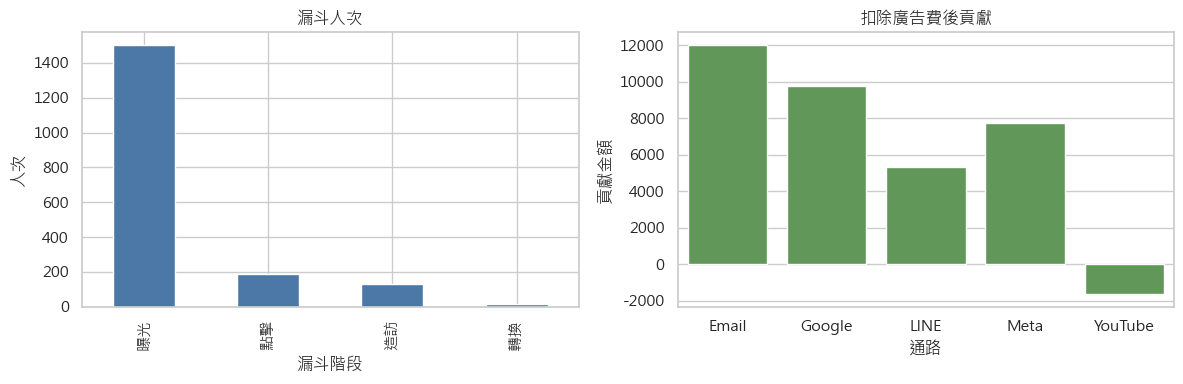

In [4]:
# 本格目的：將規模與效率分開呈現，避免只看單一百分比
funnel = pd.Series({
    "曝光": company_df["impression"].sum(),
    "點擊": company_df["clicked"].sum(),
    "造訪": company_df["visited"].sum(),
    "轉換": company_df["converted"].sum(),
})
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
funnel.plot(kind="bar", ax=axes[0], color="#4C78A8", title="漏斗人次")
sns.barplot(data=channel_kpi, x="channel", y="contribution_after_ads", ax=axes[1], color="#59A14F")
axes[1].set_title("扣除廣告費後貢獻")
axes[0].set_xlabel("漏斗階段")
axes[0].set_ylabel("人次")
axes[1].set_xlabel("通路")
axes[1].set_ylabel("貢獻金額")
plt.tight_layout()
plt.show()

#### 程式碼說明（繁體中文）

- **這段做了什麼：** 左圖顯示漏斗規模，右圖顯示扣除廣告費後的簡化貢獻。
- **預期輸出：** 兩張並列長條圖。
- **完成檢核：** 不能因 CTR 高就跳過後段轉換與成本。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D4-S05] 建立轉換機率 Logistic Regression baseline

In [5]:
# 本格目的：使用可解釋 logistic regression 預測轉換機率
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

feature_cols = ["channel", "audience_segment", "creative_type", "device", "spend", "clicked", "visited"]
categorical_features = ["channel", "audience_segment", "creative_type", "device"]
numeric_features = ["spend", "clicked", "visited"]
X = company_df[feature_cols]
y = company_df["converted"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=20260716,
)
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", StandardScaler(), numeric_features),
])
conversion_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=20260716)),
])
conversion_model.fit(X_train, y_train)
conversion_probability = conversion_model.predict_proba(X_test)[:, 1]
print("測試集轉換率：", round(float(y_test.mean()), 4))

測試集轉換率： 0.008


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 以分層切分保留轉換比例，Pipeline 完成類別編碼與 logistic regression。
- **預期輸出：** 測試集轉換率。
- **完成檢核：** 切分使用 stratify；模型預測的是機率，不是證明廣告造成轉換。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D4-S06] 評估 0.5 門檻與混淆矩陣

,threshold,precision,recall,ROC_AUC
0,0.500,0.100,0.667,0.956


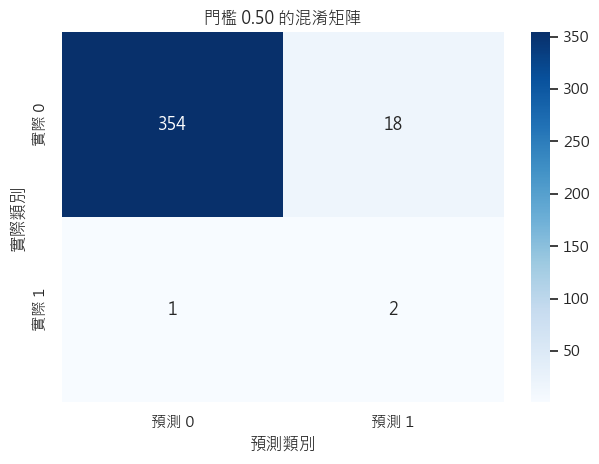

In [6]:
# 本格目的：同時查看混淆矩陣、precision、recall 與 ROC-AUC
pred_05 = (conversion_probability >= 0.50).astype(int)
metrics_05 = pd.DataFrame([{
    "threshold": 0.50,
    "precision": precision_score(y_test, pred_05, zero_division=0),
    "recall": recall_score(y_test, pred_05, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, conversion_probability),
}])
display(metrics_05.round(3))

cm = confusion_matrix(y_test, pred_05)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["預測 0", "預測 1"], yticklabels=["實際 0", "實際 1"])
plt.title("門檻 0.50 的混淆矩陣")
plt.xlabel("預測類別")
plt.ylabel("實際類別")
plt.tight_layout()
plt.show()

#### 程式碼說明（繁體中文）

- **這段做了什麼：** accuracy 容易被多數未轉換者影響，因此改看 precision、recall、AUC 與錯誤型態。
- **預期輸出：** 評估表與 2×2 混淆矩陣。
- **完成檢核：** 能指出 false positive 是投放浪費，false negative 是漏掉可能轉換者。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D4-S07] 比較三個分類門檻的取捨

,threshold,precision,recall,false_positive,false_negative
0,0.250,0.077,0.667,24,1
1,0.500,0.100,0.667,18,1
2,0.700,0.059,0.333,16,2


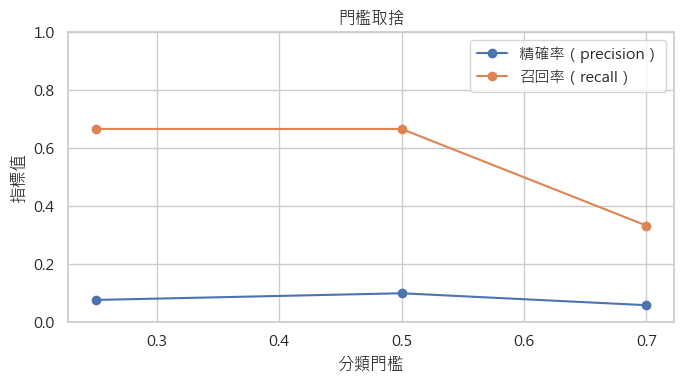

In [7]:
# 本格目的：把精準度與召回率的取捨轉成商業選擇
threshold_rows = []
for threshold in [0.25, 0.50, 0.70]:
    pred = (conversion_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    threshold_rows.append({
        "threshold": threshold, "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "false_positive": fp, "false_negative": fn,
    })
threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table.round(3))
threshold_table.plot(x="threshold", y=["precision", "recall"], marker="o", ylim=(0, 1), figsize=(7, 4))
plt.title("門檻取捨")
plt.xlabel("分類門檻")
plt.ylabel("指標值")
plt.legend(["精確率（precision）", "召回率（recall）"])
plt.tight_layout()
plt.show()

#### 程式碼說明（繁體中文）

- **這段做了什麼：** 比較 0.25、0.50、0.70，觀察抓到更多轉換者與減少浪費之間的取捨。
- **預期輸出：** 門檻表與 precision／recall 折線。
- **完成檢核：** 門檻選擇需說明媒體成本、打擾風險與企業部門承接能力。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D4-S08] 以錯誤成本選擇暫定門檻

In [8]:
# 本格目的：將 false positive 與 false negative 轉成可比較的簡化成本
# TODO：依企業情境調整兩種錯誤成本
FALSE_POSITIVE_COST = 80
FALSE_NEGATIVE_COST = 450
threshold_table["estimated_error_cost"] = (
    threshold_table["false_positive"] * FALSE_POSITIVE_COST
    + threshold_table["false_negative"] * FALSE_NEGATIVE_COST
)
best_threshold = threshold_table.sort_values("estimated_error_cost").iloc[0]
display(threshold_table.round(2))
print(f"簡化成本最低門檻：{best_threshold['threshold']:.2f}")
print("提醒：成本是假設，必須在企業資料與倫理治理下重新確認。")

,threshold,precision,recall,false_positive,false_negative,estimated_error_cost
0,0.250,0.080,0.670,24,1,2370
1,0.500,0.100,0.670,18,1,1890
2,0.700,0.060,0.330,16,2,2180


簡化成本最低門檻：0.50
提醒：成本是假設，必須在企業資料與倫理治理下重新確認。


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 用兩個透明假設把投放浪費與漏失機會換成簡化成本，協助挑門檻。
- **預期輸出：** 含估計錯誤成本的門檻表。
- **完成檢核：** 學生能說明若兩種成本改變，最佳門檻也可能改變。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D4-S09] 建立一百萬元核心與探索預算情境

In [9]:
# 本格目的：根據貢獻效率配置主要預算，同時保留探索額度
TOTAL_BUDGET = 1_000_000
EXPLORATION_SHARE = 0.20
channel_plan = channel_kpi.copy()
channel_plan["efficiency_score"] = (channel_plan["contribution_after_ads"] / channel_plan["spend"]).clip(lower=0.05)
channel_plan["core_weight"] = channel_plan["efficiency_score"] / channel_plan["efficiency_score"].sum()
channel_plan["core_budget"] = TOTAL_BUDGET * (1 - EXPLORATION_SHARE) * channel_plan["core_weight"]
channel_plan["exploration_budget"] = TOTAL_BUDGET * EXPLORATION_SHARE / len(channel_plan)
channel_plan["recommended_budget"] = (channel_plan["core_budget"] + channel_plan["exploration_budget"]).round(-3)

# 四捨五入後把差額補到最高效率通路，確保總額等於 100 萬
budget_gap = TOTAL_BUDGET - channel_plan["recommended_budget"].sum()
top_index = channel_plan["efficiency_score"].idxmax()
channel_plan.loc[top_index, "recommended_budget"] += budget_gap
display(channel_plan[["channel", "CTR", "CVR", "ROAS", "contribution_after_ads", "recommended_budget"]].round(3))
print("預算合計：", int(channel_plan["recommended_budget"].sum()))

,channel,CTR,CVR,ROAS,contribution_after_ads,recommended_budget
0,Email,0.117,0.174,63.925,"12,037.520","593,000.000"
1,Google,0.170,0.108,10.130,"9,774.570","114,000.000"
2,LINE,0.143,0.061,11.081,"5,343.958","122,000.000"
3,Meta,0.110,0.125,11.914,"7,769.070","130,000.000"
4,YouTube,0.087,0.000,0.000,"-1,646.490","41,000.000"


預算合計： 1000000


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 80% 依簡化貢獻效率配置，20% 平均保留探索，並修正四捨五入差額。
- **預期輸出：** 五通路預算表，合計 1,000,000。
- **完成檢核：** 預算不是自動投放指令；需檢查樣本量、容量與治理。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D4-S10] 整理全通路投放實驗卡草稿與繳交前檢核

In [10]:
# 本格目的：把預算建議轉成下一輪可檢驗實驗
top_channel = channel_plan.sort_values("recommended_budget", ascending=False).iloc[0]
test_card = pd.DataFrame({
    "item": ["企業", "優先測試通路", "建議門檻", "核心 KPI", "停止條件", "因果限制"],
    "content": [
        ENTERPRISE_NAME,
        top_channel["channel"],
        f"{best_threshold['threshold']:.2f}",
        "貢獻毛利、CPA、轉換數；CTR 只作前段診斷",
        "連續兩個觀察期貢獻毛利低於 0，或 CPA 高於事前上限",
        "預測誰較可能轉換，不等於廣告造成轉換；需要 A/B test 驗證增量",
    ],
})
display(test_card)
channel_plan.to_csv(OUTPUT_DIR / "Day4_全通路預算方案.csv", index=False, encoding="utf-8-sig")
test_card.to_csv(OUTPUT_DIR / "Day4_投放實驗卡.csv", index=False, encoding="utf-8-sig")

,item,content
0,企業,寶島眼鏡
1,優先測試通路,Email
2,建議門檻,0.50
3,核心 KPI,貢獻毛利、CPA、轉換數；CTR 只作前段診斷
4,停止條件,連續兩個觀察期貢獻毛利低於 0，或 CPA 高於事前上限
5,因果限制,預測誰較可能轉換，不等於廣告造成轉換；需要 A/B test 驗證增量


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 把通路、門檻、KPI、停止條件與因果限制寫成實驗卡。
- **預期輸出：** 六列實驗卡與兩個輸出 CSV。
- **完成檢核：** 至少有一項停止條件，且明確區分預測與廣告增量效果。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

## 當日學習驗收

正式作答請由課程網站進入當日 Google Form。本區只供你先確認題意與個人繳交內容，請勿在 Notebook 尋找或記錄正確選項。

### 10 題選擇題

#### 第 1 題｜基礎｜容易

CVR 在本日 Notebook 中使用哪個分母？

- A. 曝光數
- B. 點擊數
- C. 造訪數
- D. 花費

#### 第 2 題｜基礎｜容易

某通路有花費但零轉換時，CPA 最安全的呈現為何？

- A. 0
- B. 100%
- C. NaN／不可估，並回報零轉換
- D. 直接刪除通路

#### 第 3 題｜基礎｜容易

為何不能只用 CTR 分配全部預算？

- A. CTR 一定是負數
- B. CTR 不包含後段轉換、毛利與規模
- C. CTR 只能用在 Email
- D. CTR 與曝光無關

#### 第 4 題｜輸出判讀｜容易

ROC-AUC 約 0.958 最安全的解讀是什麼？

- A. 模型 95.8% 預測正確
- B. 在本測試樣本中正例排序能力較高，但仍要看門檻與正例數
- C. 廣告造成 95.8% 轉換
- D. precision 必為 0.958

#### 第 5 題｜輸出判讀｜容易

precision 低通常提醒哪一種問題？

- A. 被模型選中的名單中很多人不會轉換
- B. 真正轉換者全部被找到
- C. 模型沒有產生任何機率
- D. 訓練集一定太小

#### 第 6 題｜情境應用｜容易

把分類門檻從 0.25 提高到 0.70，通常會發生什麼？

- A. 預測為正的人數增加
- B. 預測為正的人數減少，FP 通常下降但可能漏掉更多正例
- C. AUC 必定變成 1
- D. 模型會自動重訓

#### 第 7 題｜情境應用｜中等

錯誤成本參數應由誰決定？

- A. 只由模型自動推斷
- B. 只由資料分析師決定
- C. 由業務、財務、治理與受影響觀點共同確認
- D. 永遠固定為 80 與 450

#### 第 8 題｜情境應用｜中等

保留探索預算的主要目的為何？

- A. 讓預算一定花完
- B. 持續蒐集未知通路的證據，避免只鎖定歷史冠軍
- C. 提高所有通路 CTR
- D. 取消停止條件

#### 第 9 題｜輸出判讀｜中等

模型預測某人較可能轉換，是否代表廣告造成他的轉換？

- A. 是，只要機率超過 0.5
- B. 是，只要 AUC 很高
- C. 否，預測關聯不等於因果增量，需要實驗驗證
- D. 否，所以模型完全不能用

#### 第 10 題｜情境應用｜整合

完整投放實驗卡最不可缺少哪組內容？

- A. 只有最佳通路與預算
- B. 只有模型係數
- C. 對照、主 KPI、護欄、停止條件與因果邊界
- D. 只要 CTR 圖

## 個人 Colab 實作｜17:20–18:40

使用你在網站選擇的企業專屬 Notebook，先 Restart and Run All，不必從零重做漏斗、模型與預算全流程。只調整一個分類門檻與一個預算方案，比較 precision、recall、預計名單量與錯誤成本。選出一個投放方案，用 150 字內說明門檻取捨、預算依據、一項實驗檢查與『預測不等於廣告增量』限制。

### 個人繳交內容

- 可 Restart and Run All 的企業專屬 .ipynb
- Notebook 自動產生的門檻比較與預算情境表
- 一個投放方案與 150 字內決策摘要

### 繳交前檢查

- 已從「執行階段」重新啟動並全部執行，所有儲存格無紅字。
- Notebook、CSV、圖表與摘要都對應網站所選的同一企業情境。
- 已在 Google Form 貼上可檢視的 Colab 分享網址與自己的決策摘要。
- 摘要有引用核心輸出，也有說明虛擬資料限制與下一步驗證。